# **Testing the HG Loss Function**

In [1]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
# ml imports
import torch
import torch.nn.functional as F
from tqdm import tqdm

# import module
from nlse import *

Using device: cpu


In [2]:
plt.rcParams.update({'font.size': 14})

In [3]:
num_modes = 6  # Number of HG modes for training (batch size)

# Simulation parameters
Lz = 1e-3          # Propagation length
Nz = 100          # Number of z steps
Lt = 14         # Time window
Nt = 2048        # Number of time points
N_modes = 500      # Total HG basis size
dz = Lz / Nz
dt = Lt / Nt

# Medium parameters
beta2_j = -10.0
beta2_k = -10.0
gamma_j = 1.0
gamma_k = 1.0

# Pulse parameters
tau = 0.1
amplitude_downscale = 0.1

# penalty parameters
mask_percent = 0.8
m = 8              # Number of penalty iterations


In [4]:
# Create time grid
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32, device=device)

# Define HG basis
hg_basis = get_hg_basis(N_modes, t, tau)

Precomputed 500 HG basis functions on grid of 2048 points on device cpu


## Define Useful Functions

In [5]:
# loss calculations
def time_to_trunc_hg(A, hg_basis, dt, num_modes):
    # takes as input a batch of pulses (B, Nt) and returns the HG coefficients (B, B) in the truncated basis
    if A.ndim == 1: # deal with unbatched input
        return time_to_hg(A, hg_basis[:num_modes, :], dt)
    else:
        B = A.shape[0]
        return torch.stack([time_to_hg(A[i], hg_basis[:num_modes, :], dt) for i in range(B)])  # shape: (B, B)

# plotting
def analyze(output, target, hg_basis, dt, num_modes):
    # takes an unbatched output [Nt] and a target [Nt]
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Intensity plot (plot only the middle 0.2 percent)
    intensity_output = output.abs()**2
    intensity_target = target.abs()**2
    t_plot = np.linspace(-Lt/2, Lt/2, Nt)
    mse_time = F.mse_loss(intensity_output, intensity_target).item()
    percent = 0.2  # 0.2 percent as fraction
    Nt_middle = int(Nt * percent)
    left_idx = (Nt - Nt_middle) // 2
    right_idx = left_idx + Nt_middle
    axs[0].plot(t_plot[left_idx:right_idx], intensity_target[left_idx:right_idx], label='Target |A|^2', color = 'r')
    axs[0].plot(t_plot[left_idx:right_idx], intensity_output[left_idx:right_idx], label='Output |A|^2', linestyle='--', color = 'b')
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Intensity")
    axs[0].set_title(f"Pulse Intensity (MSE={mse_time:.3e})")
    axs[0].legend()
    axs[0].grid(True)

    # 2. HG Coefficient plot (now as a stem plot)
    coeff_output = time_to_trunc_hg(output, hg_basis, dt, num_modes).numpy()
    coeff_target = time_to_trunc_hg(target, hg_basis, dt, num_modes).numpy()
    coeff_output_int = np.abs(coeff_output)**2
    coeff_target_int = np.abs(coeff_target)**2
    mse_hg = np.mean(coeff_output_int - coeff_target_int)
    mode_indices = np.arange(num_modes)
    axs[1].stem(mode_indices, coeff_target_int, label='Target HG Coeff.', basefmt=' ', linefmt='r-', markerfmt='ro')
    axs[1].stem(mode_indices, coeff_output_int, label='Output HG Coeff.', basefmt=' ', linefmt='b-', markerfmt='bo')
    axs[1].set_xlabel("Truncated HG Mode n")
    axs[1].set_ylabel("Coeff Amplitude")
    axs[1].set_title(f"Truncated HG Coefficient \"Intensity\" (MSE={mse_hg:.3e})")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_inputs(x, A_strong, mask):
    # x [Nt], A_strong [Nt], mask [Nt]
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot input pulse mode n
    axs[0].plot(t, x, label=f"Input pulse", color = 'b')
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Amplitude")
    axs[0].set_title(f"Input Pulse")
    axs[0].grid(True)
    axs[0].legend()

    # Plot strong pulse and penalty mask
    axs[1].plot(t, A_strong, label="Strong Pulse", color = 'r')
    axs[1].plot(t, mask, '--', label="Penalty Mask", color = 'k')
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Amplitude / Mask")
    axs[1].set_title("Strong Pulse and Penalty Mask")
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

## Initialize Inputs and Targets

Precomputed 6 HG basis functions on grid of 2048 points on device cpu


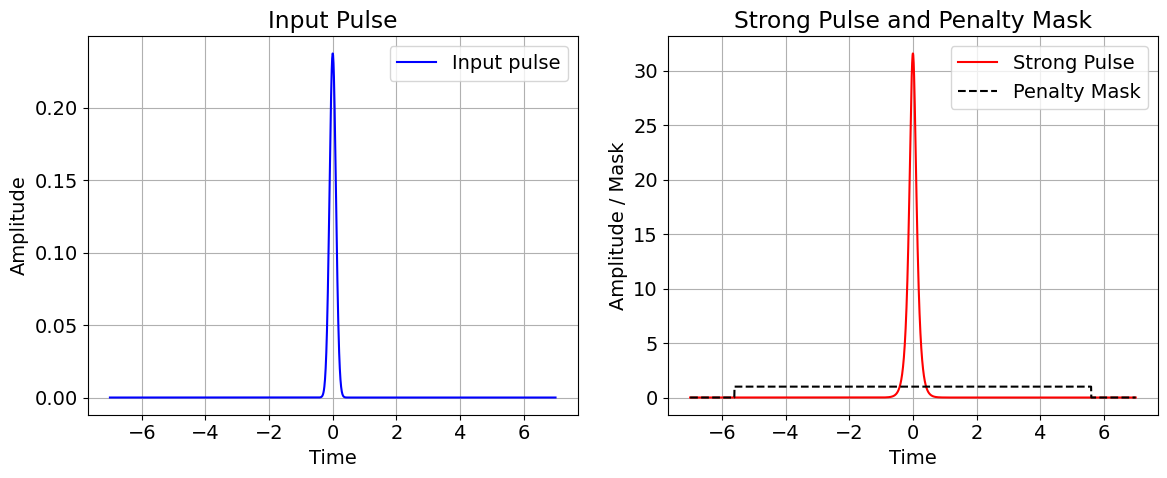

Input: torch.Size([2048])
Target: torch.Size([2048])


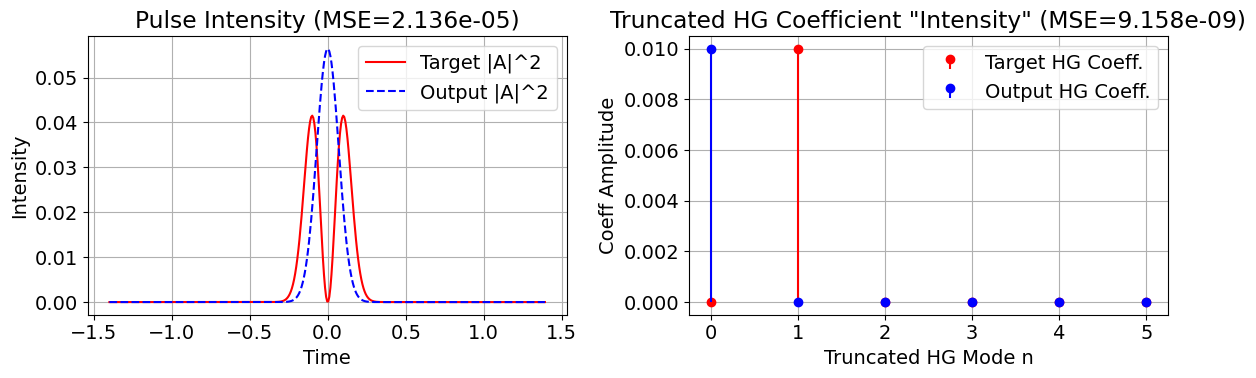

In [ ]:
"""--------Input Weak Pulses--------"""
# Get batch of pulses (using num_modes)
B = num_modes
x = get_hg_basis(B, t, tau) * amplitude_downscale  # inputs

"""--------Target Weak Pulses--------"""
y = x.clone().detach()  # labels (identity operator)
y_hg = time_to_trunc_hg(y, hg_basis, dt, num_modes)

"""--------Input Strong Pulse--------"""	
# Define input strong pulse (soliton)
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    return Ain_k

A_strong = strong_soliton(t, beta2_k, gamma_k, tau)
A_strong_hg = time_to_hg(A_strong, hg_basis, dt)

"""--------Penalty Mask--------"""
# Define penalty mask
penalty = torch.zeros_like(t, device=device)
penalty[:int(Nt/2 - Nt*mask_percent/2)] = 1
penalty[int(Nt/2 + Nt*mask_percent/2):] = 1
mask = 1 - penalty
iters = np.linspace(0, Nz-1, m).astype(int)


"""--------Plotting--------"""
n = 0  # You can choose any valid mode here
plot_inputs(x[n], A_strong, mask)

# test plot
output = x[n]
target = y[n+1]
analyze(output, target, hg_basis, dt, num_modes)

## Run Training

In [7]:
# Training parameters
w_mse = 1e4	        # MSE loss weight
w_pen = 1e3        # Penalty loss weight
lr = 0.1          # Learning rate
N_train = 500      # Number of training iterations (small for quick testing)

# Analysis Parameters
analysis_mode = num_modes - 1 # analyze the last mode
analyze_every = 50 # analyze every N iterations

In [8]:
"""--------Loss Functions--------"""
def hg_loss_function(A_j_evolution, A_k_evolution):
    final_j = A_j_evolution[:, :, -1]  # shape: (B, Nt)
    final_j_hg = time_to_trunc_hg(final_j, hg_basis, dt, num_modes)  # shape: (B, B)
    mse_loss = torch.sum(torch.abs(final_j_hg)**2 - torch.abs(y_hg)**2)
    
    pen_loss = 0.0
    zeros = torch.zeros(B, Nt, dtype=torch.float32, device=device)
    # Penalization loss - to enforce none of the waves to stray outside the simulation bounds
    for i in iters:
        pen_loss = pen_loss + F.mse_loss(torch.abs(A_k_evolution[:, :, i]*penalty)**2, zeros)
        
    return w_mse * mse_loss, w_pen * pen_loss

Training:   0%|          | 0/500 [00:00<?, ?it/s]c:\Users\lukas\OneDrive - Yale University\Personal\Studies\Lab\LGW-Lab-NLSE\NLSE in PyTorch\nlse.py:398: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at ..\aten\src\ATen\native\Copy.cpp:301.)
  return A.float()


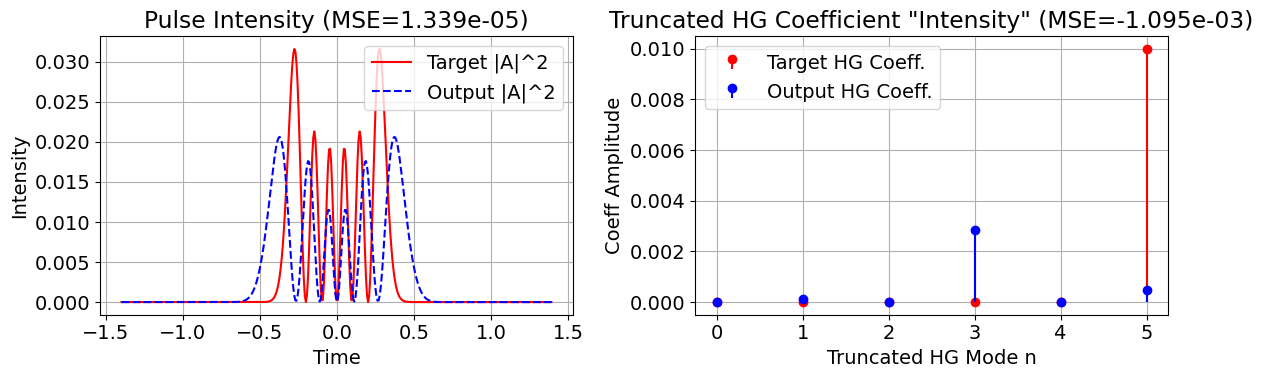

Training:  10%|█         | 50/500 [01:25<13:53,  1.85s/it]

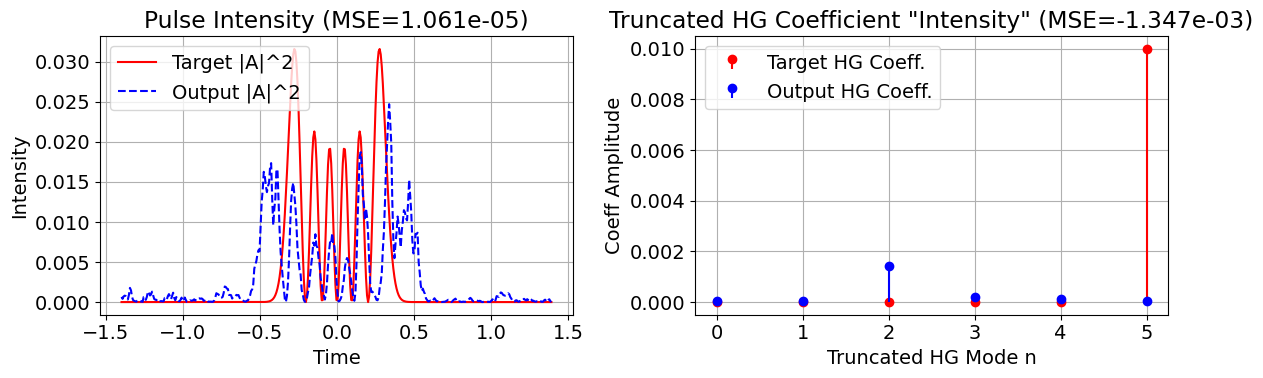

Training:  20%|██        | 100/500 [03:05<12:59,  1.95s/it]

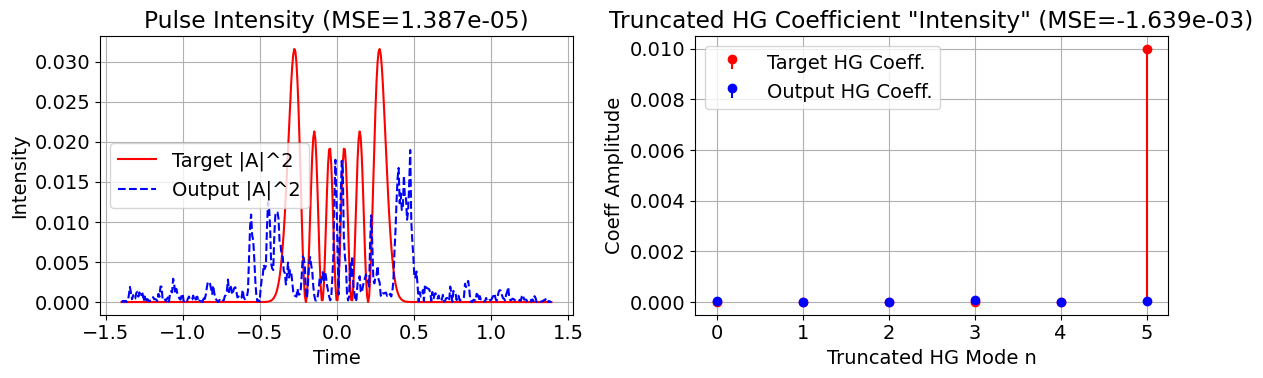

Training:  30%|███       | 150/500 [04:57<10:47,  1.85s/it]

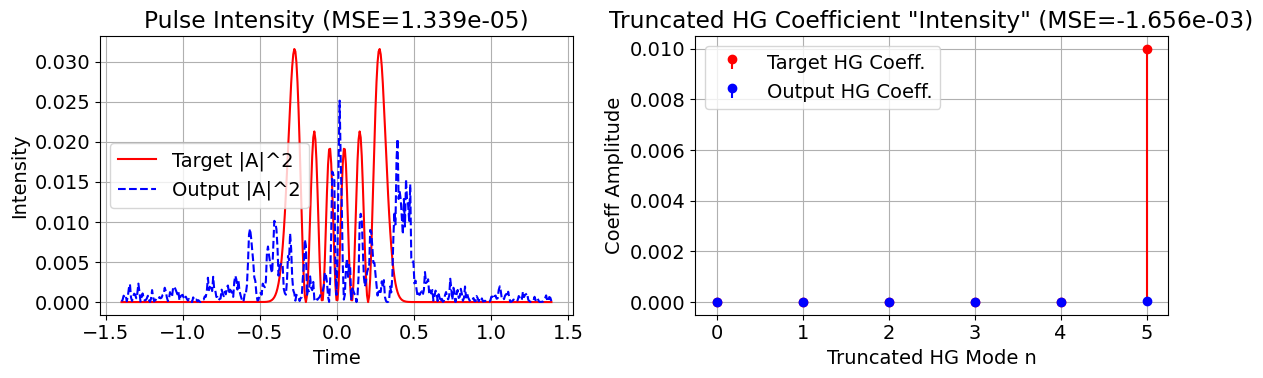

Training:  40%|████      | 200/500 [06:27<09:26,  1.89s/it]

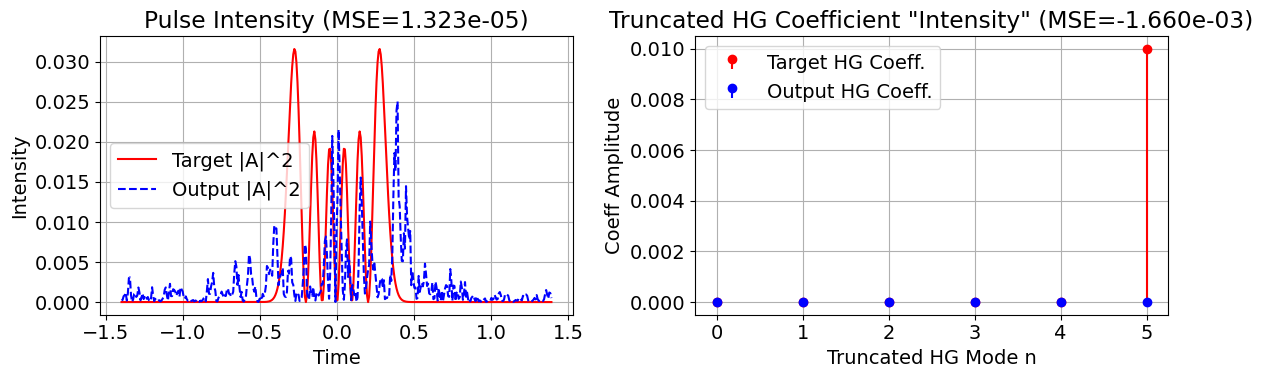

Training:  50%|█████     | 250/500 [08:09<07:38,  1.83s/it]

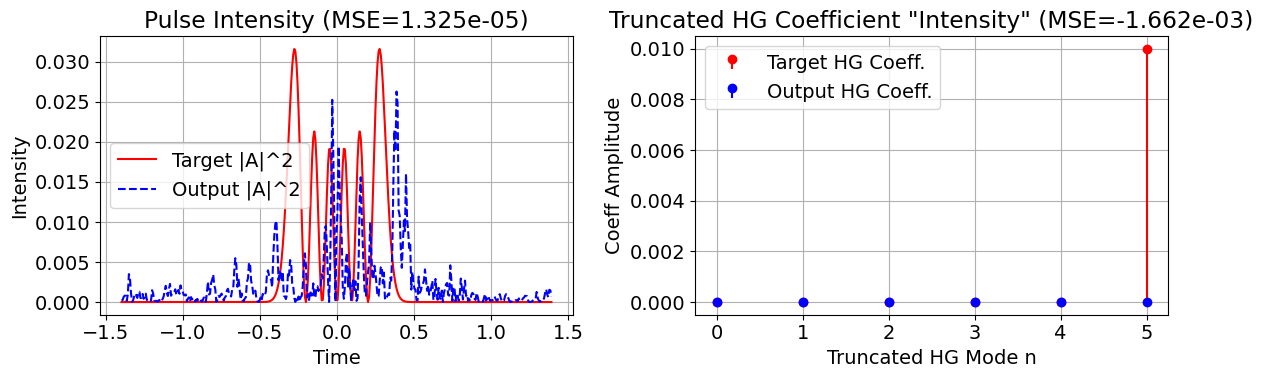

Training:  51%|█████     | 255/500 [08:19<07:59,  1.96s/it]


KeyboardInterrupt: 

In [9]:
# Initialize theta
theta = torch.nn.Parameter(A_strong_hg.clone().detach().requires_grad_(True))
optimizer = torch.optim.Adam([theta], lr=lr)
loss_fn = hg_loss_function

losses_mse = []
losses_pen = []
losses_total = []

# Training loop
for i in tqdm(range(N_train), desc="Training"):
    optimizer.zero_grad()
    Ain_k = hg_to_time(theta, hg_basis)
    A_j_evolution, A_k_evolution = split_step_fourier_xpm_batch(x, Ain_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    loss_mse, loss_pen = loss_fn(A_j_evolution, A_k_evolution)
    loss = loss_mse + loss_pen
    loss.backward()
    optimizer.step()

    losses_mse.append(loss_mse.item())
    losses_pen.append(loss_pen.item())
    losses_total.append(loss.item())
    
    # every 5 iterations, analyze
    if i % analyze_every == 0:
        with torch.no_grad():
            analyze(A_j_evolution[analysis_mode, :, -1], A_j_evolution[analysis_mode, :, 0], hg_basis, dt, num_modes)

## Analyze Results

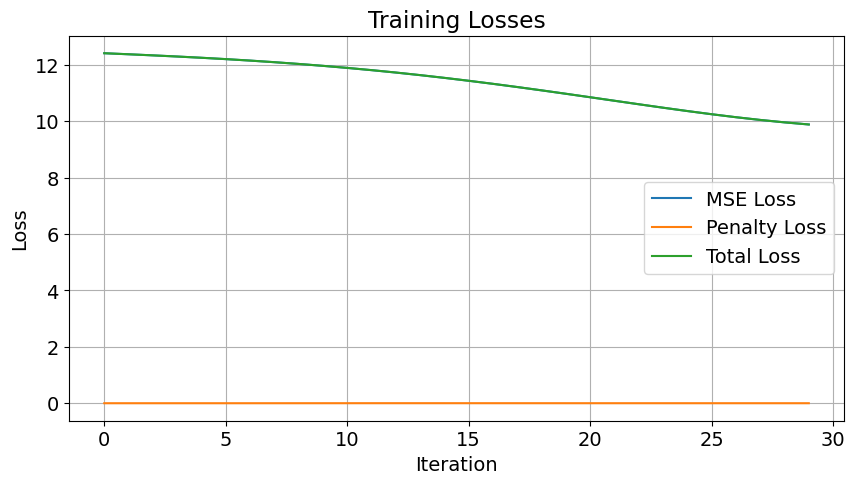

In [ ]:
# Plot losses
plt.figure(figsize=(10,5))
plt.plot(losses_mse, label="MSE Loss")
plt.plot(losses_pen, label="Penalty Loss")
plt.plot(losses_total, label="Total Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.grid()
plt.show()